<a href="https://colab.research.google.com/github/karrielaugustin001-del/Machine-Learning-Foundations/blob/main/Unit_6_Assignment_KA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 — Clustering & PCA Analysis (Student Starter Notebook)

**Goal:** Apply **K-Means**, **Hierarchical Clustering**, and **DBSCAN** on a large dataset, then use **PCA** (and optional **t-SNE**) for visualization and interpretation.

## Datasets (in `data/`)
- `customer_segments_large.csv`
- `anomaly_transactions_large.csv`
- `highdim_behavior_50f.csv`

---


## Step 1 — Imports


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

## Step 2 — Load a dataset


In [9]:
# TODO: Choose ONE dataset
DATA_PATH = "/content/customer_segments_large.csv"  # or anomaly_transactions_large.csv or highdim_behavior_50f.csv

df = pd.read_csv(DATA_PATH)
display(df.head())
print("Shape:", df.shape)
display(df.isna().mean().sort_values(ascending=False))

,Age,SpendingScore,AnnualIncome,VisitsPerMonth,TenureMonths,WebEngagementScore
0,30,23,48754,3.3,1,20
1,29,31,41849,1.2,19,52
2,28,49,46208,1.2,15,26
3,32,34,40336,1.4,22,38
4,26,31,46791,2.6,15,46


Shape: (10000, 6)


,0
Age,0.0
SpendingScore,0.0
AnnualIncome,0.0
VisitsPerMonth,0.0
TenureMonths,0.0
WebEngagementScore,0.0


## Step 3 — Explore


In [10]:
# Inspect dataset using summary statistics
df.describe()


,Age,SpendingScore,AnnualIncome,VisitsPerMonth,TenureMonths,WebEngagementScore
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,39.359100,52.503700,70553.628000,3.633410,31.388400,50.597500
std,12.648365,19.985963,24790.312547,1.918586,22.929399,19.015416
min,18.000000,1.000000,15000.000000,0.000000,1.000000,0.000000
25%,30.000000,37.000000,49642.250000,2.200000,13.000000,37.000000
50%,37.000000,51.000000,70818.500000,3.400000,26.000000,52.000000
75%,47.000000,69.000000,87841.250000,4.900000,45.000000,65.000000
max,85.000000,100.000000,162604.000000,12.900000,143.000000,100.000000


In [11]:
df.isna().sum()


,0
Age,0
SpendingScore,0
AnnualIncome,0
VisitsPerMonth,0
TenureMonths,0
WebEngagementScore,0


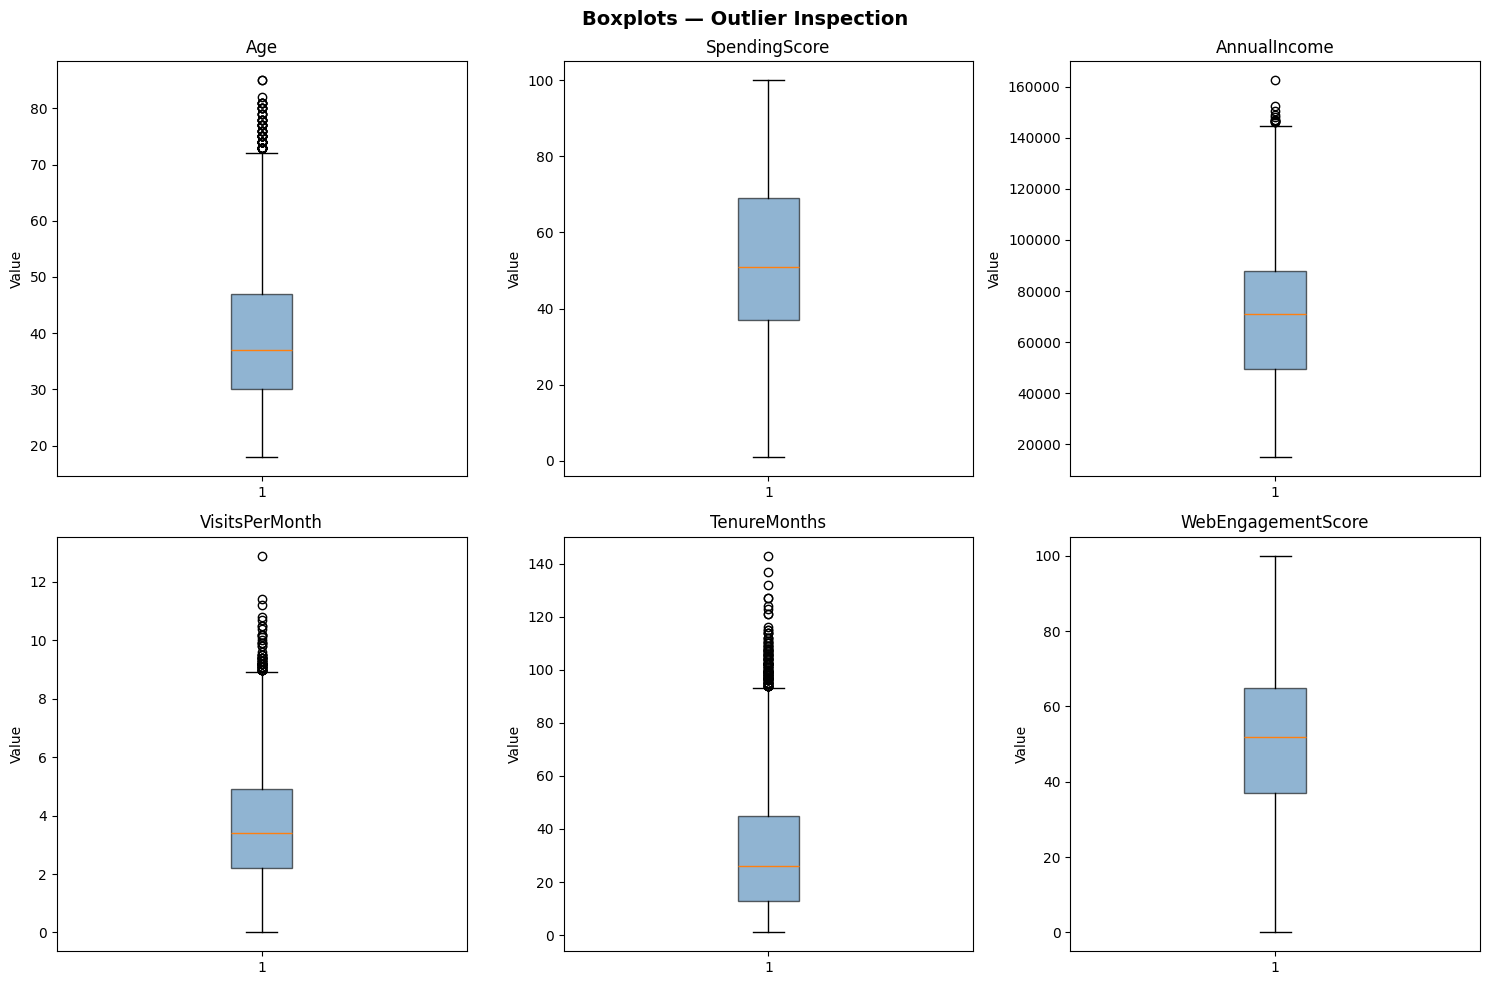

In [12]:
import matplotlib.pyplot as plt
# Visualize outliers with boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    ax = axes[i // 3][i % 3]
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("Value")
plt.suptitle("Boxplots — Outlier Inspection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ✍️ Reflection (3–6 sentences)
- What patterns do you expect before clustering?

Before applying clustering algorithms, several potential behavioral patterns may exist within the customer dataset. Based on the summary statistics, customers likely vary in terms of income level, spending behavior, engagement frequency, and loyalty duration. For example, some customers may have high annual income and high spending scores, indicating premium or high-value customers, while others may have moderate income but frequent visits, suggesting highly engaged but lower-spending customers. Another possible pattern is a group of long-tenure customers with consistent engagement over time, representing loyal customers. Additionally, younger customers may demonstrate higher web engagement scores and visit frequency, reflecting stronger digital interaction compared to older customer segments.
- Which features likely drive similarity?

Several features are likely to drive similarity between customers during clustering. SpendingScore and AnnualIncome are expected to be strong drivers because they represent purchasing power and spending behavior, which are often key indicators in customer segmentation. VisitsPerMonth and WebEngagementScore may also contribute significantly because they reflect customer engagement and interaction with the business. TenureMonths could identify long-term loyal customers versus newer customers, while Age may influence lifestyle patterns and purchasing behavior. Together, these variables capture both behavioral and demographic characteristics, allowing the clustering algorithms to group customers with similar economic and engagement profiles.


## Step 4 — Scale numeric features


In [13]:
# Apply outlier caps based on domain knowledge
df_clean = df.copy()
df_clean['AnnualIncome']     = df_clean['AnnualIncome'].clip(upper=150000)
df_clean['VisitsPerMonth']   = df_clean['VisitsPerMonth'].clip(upper=10)
df_clean['TenureMonths']     = df_clean['TenureMonths'].clip(upper=120)

# Scale numeric features
num_df = df_clean.select_dtypes(include=[np.number]).copy()
scaler = StandardScaler()
X = scaler.fit_transform(num_df)

print("Scaled feature matrix shape:", X.shape)
print("Features:", list(num_df.columns))


Scaled feature matrix shape: (10000, 6)
Features: ['Age', 'SpendingScore', 'AnnualIncome', 'VisitsPerMonth', 'TenureMonths', 'WebEngagementScore']


## Step 5 — K-Means (try multiple K values)


In [14]:
# Sweep K from 2 to 10
results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    results.append((k, km.inertia_, round(sil, 4)))

results_df = pd.DataFrame(results, columns=["K", "Inertia", "Silhouette"])
display(results_df)


,K,Inertia,Silhouette
0,2,42218.290230,0.2889
1,3,27800.885092,0.3567
2,4,24038.644306,0.2808
3,5,22527.312289,0.2519
4,6,21355.384732,0.1869
5,7,20268.536352,0.1693
6,8,19425.857027,0.1617
7,9,18819.417843,0.1556
8,10,18262.929315,0.1553


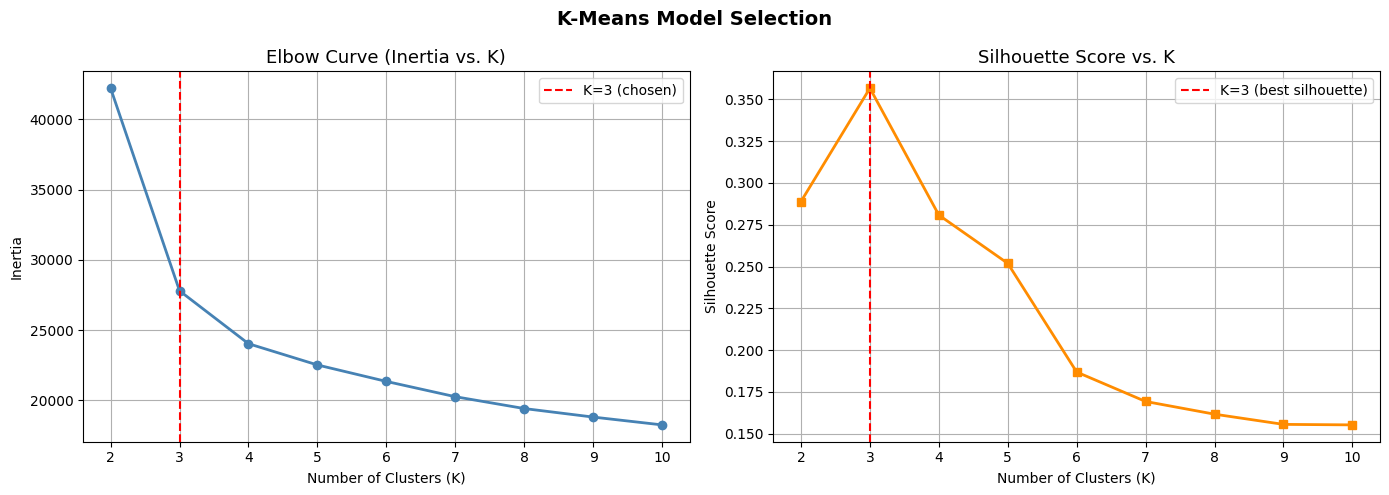

In [15]:
# Plot Elbow Curve and Silhouette Scores side by side
k_values   = results_df["K"].tolist()
inertias   = results_df["Inertia"].tolist()
silhouettes = results_df["Silhouette"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', label='K=3 (chosen)')
axes[0].set_title("Elbow Curve (Inertia vs. K)", fontsize=13)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(k_values, silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].axvline(x=3, color='red', linestyle='--', label='K=3 (best silhouette)')
axes[1].set_title("Silhouette Score vs. K", fontsize=13)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("K-Means Model Selection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# TODO: Choose final K and justify
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X)

print(f"Final K: {K_FINAL}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X, labels_km):.4f}")
print(f"\nCluster sizes:")
unique, counts = np.unique(labels_km, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} customers ({c/len(labels_km)*100:.1f}%)")



Final K: 3
Inertia: 27800.89
Silhouette Score: 0.3567

Cluster sizes:
  Cluster 0: 3155 customers (31.6%)
  Cluster 1: 2603 customers (26.0%)
  Cluster 2: 4242 customers (42.4%)


In [17]:
# Interpret cluster centers (original scale)
centers_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=num_df.columns
).round(1)
centers_df.index = [f"Cluster {i}" for i in range(K_FINAL)]
print("Cluster Centers (original scale):")
display(centers_df)

# Assign human-readable labels
cluster_names = {0: "Young Budget Customers", 1: "Wealthy Senior Loyalists", 2: "Core Engaged Customers"}
df_clean['Cluster'] = labels_km
df_clean['Segment'] = df_clean['Cluster'].map(cluster_names)
print("\nSegment distribution:")
print(df_clean['Segment'].value_counts())

Cluster Centers (original scale):


,Age,SpendingScore,AnnualIncome,VisitsPerMonth,TenureMonths,WebEngagementScore
Cluster 0,29.2,35.9,43755.7,2.3,14.1,40.8
Cluster 1,55.7,45.4,92803.0,3.0,58.3,38.0
Cluster 2,36.9,69.2,76785.7,5.0,27.7,65.6



Segment distribution:
Segment
Core Engaged Customers      4242
Young Budget Customers      3155
Wealthy Senior Loyalists    2603
Name: count, dtype: int64


## Step 6 — Hierarchical clustering (dendrogram on subset)


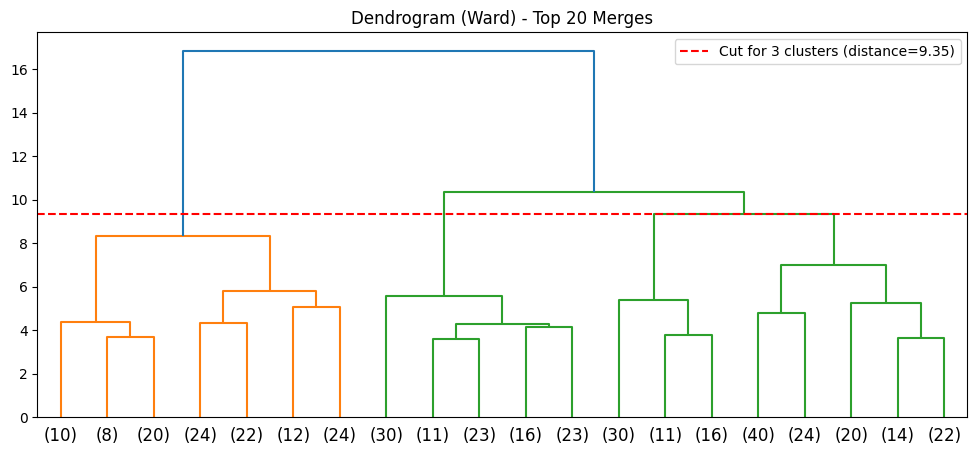

Hierarchical clusters found: 3
Silhouette (hierarchical, subset): 0.1228


In [33]:
subset_n = 400
# Select the linkage method 'ward', 'single', 'average' or 'complete'
Z = linkage(X[:subset_n], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=20, show_leaf_counts=True)
plt.title("Dendrogram (Ward) - Top 20 Merges")
# Add a horizontal line to show the cut threshold for 3 clusters
max_d_3_clusters = Z[len(Z) - 3, 2] # The distance value for the merge that results in 3 clusters
plt.axhline(y=max_d_3_clusters, color='r', linestyle='--', label=f'Cut for 3 clusters (distance={max_d_3_clusters:.2f})')
plt.legend()
plt.show()

# Cut the dendrogram at 3 clusters
hier_labels = fcluster(Z, t=3, criterion='maxclust')
print(f"Hierarchical clusters found: {len(np.unique(hier_labels))}")
print(f"Silhouette (hierarchical, subset): {silhouette_score(X[:subset_n], hier_labels):.4f}")

## Step 7 — DBSCAN (eps sweep)


In [44]:
def dbscan_summary(eps, min_samples=10):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)
    unique, counts = np.unique(labels, return_counts=True)
    summary = dict(zip(unique, counts))
    n_clusters = len([k for k in summary.keys() if k != -1])
    n_noise = summary.get(-1, 0)
    # Calculate percentage of noise
    total_samples = len(X)
    noise_pct = (n_noise / total_samples) * 100 if total_samples > 0 else 0
    return n_clusters, n_noise, noise_pct

for eps in [0.2, 0.3, 0.5, 0.8, 1.0,1.5]:
    n_clusters, n_noise, noise_pct = dbscan_summary(eps, min_samples=10)
    print(f"eps={eps} -> clusters={n_clusters}, noise={n_noise} (noise pct: {noise_pct:.1f}%)")

eps=0.2 -> clusters=0, noise=10000 (noise pct: 100.0%)
eps=0.3 -> clusters=0, noise=10000 (noise pct: 100.0%)
eps=0.5 -> clusters=15, noise=7927 (noise pct: 79.3%)
eps=0.8 -> clusters=1, noise=1308 (noise pct: 13.1%)
eps=1.0 -> clusters=1, noise=268 (noise pct: 2.7%)
eps=1.5 -> clusters=1, noise=4 (noise pct: 0.0%)


## Step 8 — PCA (2D)


In [35]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.3738672 0.338089 ]
Total explained: 0.7119562063216799


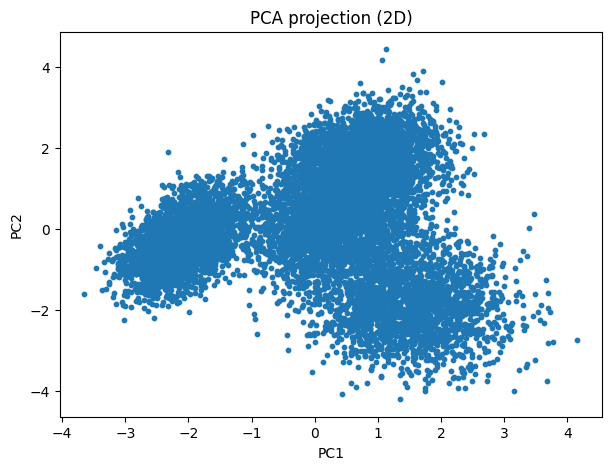

In [36]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
plt.title("PCA projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


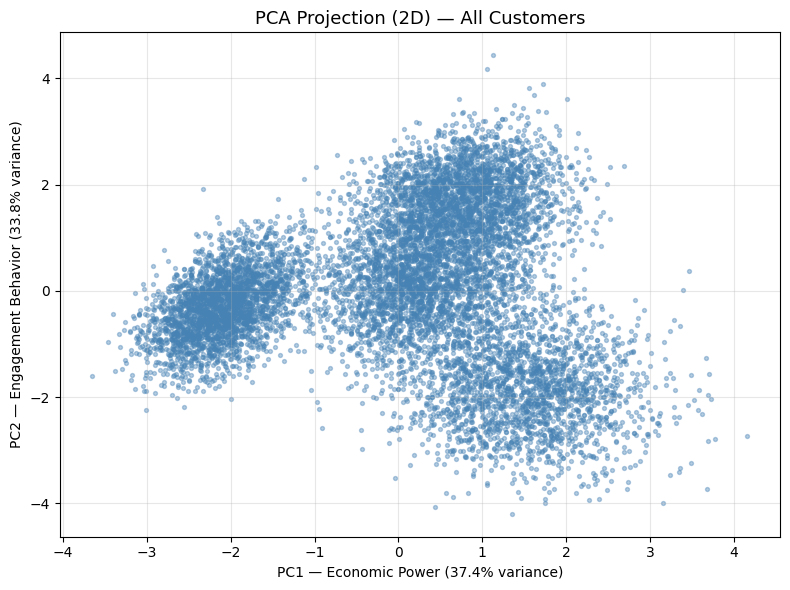

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.4, color='steelblue')
plt.title("PCA Projection (2D) — All Customers", fontsize=13)
plt.xlabel(f"PC1 — Economic Power ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 — Engagement Behavior ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9 — Visualize clusters in PCA space (required)


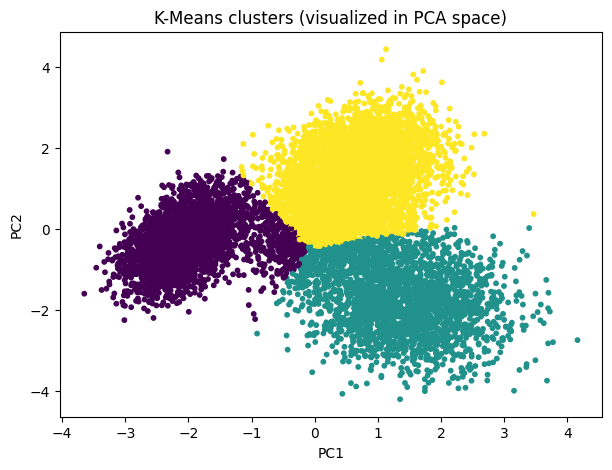

In [37]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, s=10)
plt.title("K-Means clusters (visualized in PCA space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## Step 10 — Optional: t-SNE (advanced/bonus)


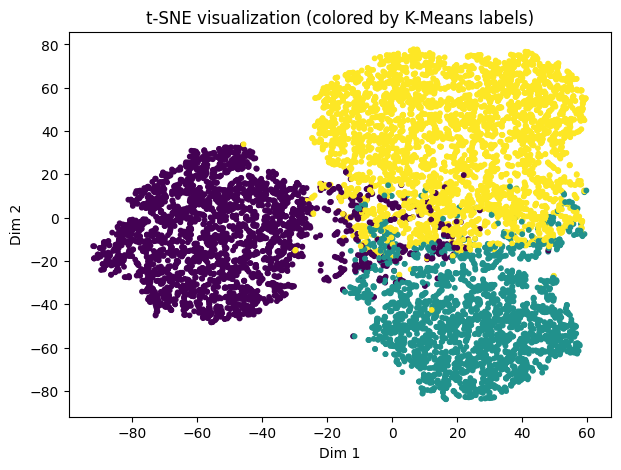

In [38]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_km, s=10)
plt.title("t-SNE visualization (colored by K-Means labels)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()
